# Palmer Archipelago Dataset Hypothesis Tests

## Description

This dataset contains **morphological measurements of penguins** collected in the **Palmer Archipelago, Antarctica**.
It’s often used as an educational dataset in data science as a more interesting substitute for the classic *iris* dataset.  
The data were collected from **three penguin species** during field studies conducted between **2007 and 2009** by the Palmer Station Long Term Ecological Research (LTER) program.  

Rows typically represent individual penguin observations with measurements of body size and other features.

| Column Name            | Description                                                                 |
|------------------------|-----------------------------------------------------------------------------|
| `species`              | Penguin species (e.g., Adelie, Chinstrap, Gentoo). Categorical label.      |
| `island`               | Island in the Palmer Archipelago where the penguin was observed (Biscoe, Dream, Torgersen). |
| `culmen_length_mm`     | Length of the penguin’s bill (culmen) in millimeters.                       |
| `culmen_depth_mm`      | Depth (height) of the penguin’s bill in millimeters.                        |
| `flipper_length_mm`    | Length of the penguin’s flippers in millimeters.                             |
| `body_mass_g`          | Body mass (weight) of the penguin in grams.                                  |
| `sex`                  | Penguin’s sex (male or female). May contain missing values (NA).             |
| `year`                 | Year the observation was recorded (typically 2007, 2008, or 2009).

## In this dataset, the following statistical techniques were used:

### Hypothesis Tests
- _One-way ANOVA_
- _Shapiro-Wilk test_ (goodness-of-fit, $W$)
- _Bartlett's test_
- _Levene's test_
- _Tukey's HSD_ (post-hoc)
- _Chi-square test of independence_ ($\chi^2$)
- _t-test_

### Correlations and Measures of Association
- _Spearman's rank correlation coefficient_ ($\rho$)
- _Pearson correlation coefficient_ ($r$)
- _Cramér's V_ ($V$)
- _Phi coefficient_ ($\phi$)
- _Pearson's contingency coefficient (C)_ ($C$)

## Libraries import

In [106]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from bioinfokit.analys import stat

## Dataset import

In [107]:
kagglehub.dataset_download("parulpandey/palmer-archipelago-antarctica-penguin-data", output_dir="data", force_download=True)

100%|██████████| 11.3k/11.3k [00:00<00:00, 5.80MB/s]

Extracting files...


'data'

In [108]:
df = pd.read_csv('data/penguins_lter.csv')

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Region               344 non-null    object 
 4   Island               344 non-null    object 
 5   Stage                344 non-null    object 
 6   Individual ID        344 non-null    object 
 7   Clutch Completion    344 non-null    object 
 8   Date Egg             344 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    flo

In [110]:
df.sample(5)

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
53,PAL0809,54,Adelie Penguin (Pygoscelis adeliae),Anvers,Biscoe,"Adult, 1 Egg Stage",N22A2,Yes,11/9/08,42.0,19.5,200.0,4050.0,MALE,8.48095,-26.31460,NaN
26,PAL0708,27,Adelie Penguin (Pygoscelis adeliae),Anvers,Biscoe,"Adult, 1 Egg Stage",N17A1,Yes,11/12/07,40.6,18.6,183.0,3550.0,MALE,8.93997,-25.36288,NaN
39,PAL0708,40,Adelie Penguin (Pygoscelis adeliae),Anvers,Dream,"Adult, 1 Egg Stage",N25A2,No,11/13/07,39.8,19.1,184.0,4650.0,MALE,NaN,NaN,Nest never observed with full clutch. Not enou...
93,PAL0809,94,Adelie Penguin (Pygoscelis adeliae),Anvers,Dream,"Adult, 1 Egg Stage",N46A2,Yes,11/5/08,39.6,18.1,186.0,4450.0,MALE,8.49915,-26.42406,NaN
9,PAL0708,10,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N5A2,Yes,11/9/07,42.0,20.2,190.0,4250.0,NaN,9.13362,-25.09368,No blood sample obtained for sexing.


Drop null data

In [111]:
df.isna().sum()

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     10
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               318
dtype: int64

In [112]:
df = df.dropna(subset=[col for col in df.columns if col != 'Comments'])

In [113]:
df.isna().sum()

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       0
Culmen Depth (mm)        0
Flipper Length (mm)      0
Body Mass (g)            0
Sex                      0
Delta 15 N (o/oo)        0
Delta 13 C (o/oo)        0
Comments               312
dtype: int64

## Correlation for Numerical Variables

### Relationship Between Body Mass (body_mass_g) and Flipper Length (flipper_length_mm)

### Pearson Correlation Coefficient

The **Pearson correlation coefficient** ($r$) is a measure of the **linear relationship** between two **continuous numerical variables**.
It quantifies both the **strength** and **direction** of the association.

### Formula

For two variables $X$ and $Y$ with $n$ observations:

$$
r = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}
$$

Where:

- $X_i$, $Y_i$ – individual observations
- $\bar{X}$, $\bar{Y}$ – sample means of $X$ and $Y$
- $n$ – number of observations

### Range of Values

$$
-1 \le r \le 1
$$

- $r = 1$ → perfect positive linear relationship
- $r = -1$ → perfect negative linear relationship
- $r = 0$ → no linear relationship

### Hypotheses (for significance testing)

- $H_0$: $r = 0$ → no linear correlation
- $H_1$: $r \ne 0$ → significant linear correlation

### Assumptions / Conditions Before Using Pearson Correlation

1. **Linearity** – the relationship between the variables should be approximately linear
2. **Normality** – both variables should be approximately normally distributed
   - Can be checked using tests like **Shapiro-Wilk**
3. **Homoscedasticity** – the variance of one variable should be roughly constant across the values of the other variable
4. **Independence of observations** – each observation is independent of the others
5. **No strong outliers** – extreme values can distort the correlation and lead to misleading results. Consider visualizing the data with a **scatter plot** before calculating the correlation.

<b> We will use Pearson’s Correlation Coefficient test (when assumptions meet) </b>

In [145]:
df['Flipper Length (mm)'].describe()

count    325.000000
mean     201.264615
std       13.964598
min      172.000000
25%      190.000000
50%      197.000000
75%      213.000000
max      231.000000
Name: Flipper Length (mm), dtype: float64

**Assumptions:**  
1. Observations in each sample are independent and distributed identically. 
2. Observations are normally distributed.
3. Similar variance between independent variables    

- **H0**: There is no correlation between the two variables.
- **HA**: There is a correlation between the two variables.

### Normality test

1. QQ plot check

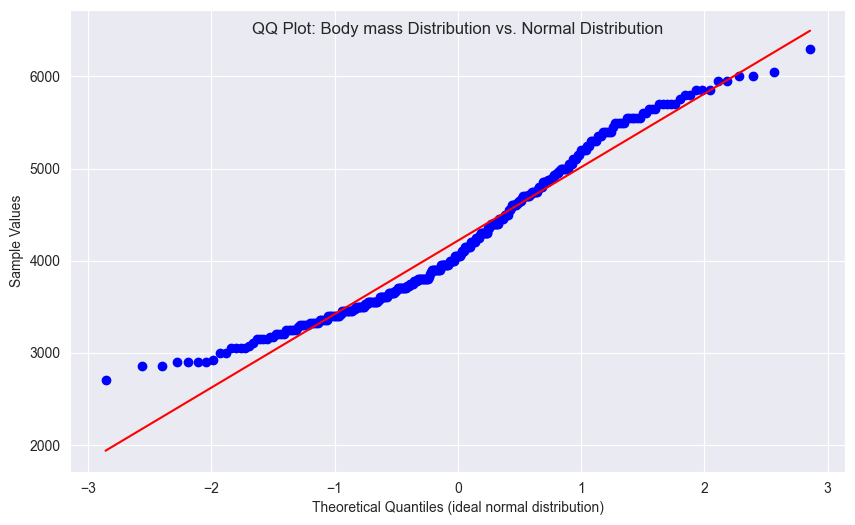

In [146]:
fig = plt.figure(figsize=(10,6))

stats.probplot(df['Body_mass'], dist='norm', plot=plt)

plt.xlabel('Theoretical Quantiles (ideal normal distribution)')
plt.ylabel('Sample Values')

plt.title("QQ Plot: Body mass Distribution vs. Normal Distribution", y=0.93)
plt.show()

2. Shapiro-Wilk test

- **H0**: The data is normally distributed 
- **HA**: The data is **not normally distributed**

In [147]:
shapiro_test = stats.shapiro(df['Body_mass'])

print(f"Shapiro-Wilk test statistic for body mass: {shapiro_test.statistic:.4f}")
print(f"p-value for body mass {name}: {shapiro_test.pvalue:.4f}")

if shapiro_test.pvalue > alpha:
    print("Fail to reject H0 – the distribution can be considered normal \n")
else:
    print("Reject H0 – the distribution is not normal \n")

Shapiro-Wilk test statistic for body mass: 0.9596
p-value for body mass Gentoo penguin (Pygoscelis papua): 0.0000
Reject H0 – the distribution is not normal 



The distribution is not normal, so we will use **Spearman’s Rank Correlation** instead of Pearson’s correlation.

### Spearman’s Rank Correlation Coefficient

**Spearman’s rank correlation coefficient** ($\rho$ or $r_s$) is a **non-parametric measure** of the **monotonic relationship** between two variables.
It is used when the **assumptions of Pearson correlation** (normality, linearity) are **not met**, or when dealing with **ordinal data**.

### Idea

- Instead of using raw data values, Spearman’s correlation uses **ranks** of the data.
- It measures whether **as one variable increases, the other tends to increase or decrease**, without assuming linearity.

### Formula

For a sample of size $n$, with ranks $R(X_i)$ and $R(Y_i)$:

$$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$

Where:

- $d_i = R(X_i) - R(Y_i)$ – difference between ranks of the $i$-th observation
- $n$ – number of observations

### Range of Values

$$
-1 \le \rho \le 1
$$

- $\rho = 1$ → perfect increasing monotonic relationship
- $\rho = -1$ → perfect decreasing monotonic relationship
- $\rho = 0$ → no monotonic relationship

### Hypotheses (for significance testing)

- $H_0$: $\rho = 0$ → no monotonic association
- $H_1$: $\rho \ne 0$ → significant monotonic association

### Assumptions / Conditions

1. **Variables can be ordinal, interval, or ratio**
2. **Observations are independent**
3. **Relationship is monotonic**, not necessarily linear
4. **Outliers affect the coefficient less than Pearson’s correlation**, but extreme ranks can still have some impact

### Notes

- Spearman’s correlation is **robust to non-normal data**.
- Often used when data contain **outliers** or when testing **ranked/ordinal variables**.
- Can be computed using either **ranks** or **a formula based on the difference of ranks** as shown above.

In [148]:
stat, p = stats.spearmanr(df['Body_mass'], df['Flipper Length (mm)'])

In [149]:
print('stat={0:.3g}, p={0:.3f}'.format(stat, p))
if p > alpha:
    print('Fail to reject H0 – There is propably no correlation between the two variables.\n')
else:
    print('Reject H0 - There is a correlation between the two variables.')

stat=0.849, p=0.849
Reject H0 - There is a correlation between the two variables.


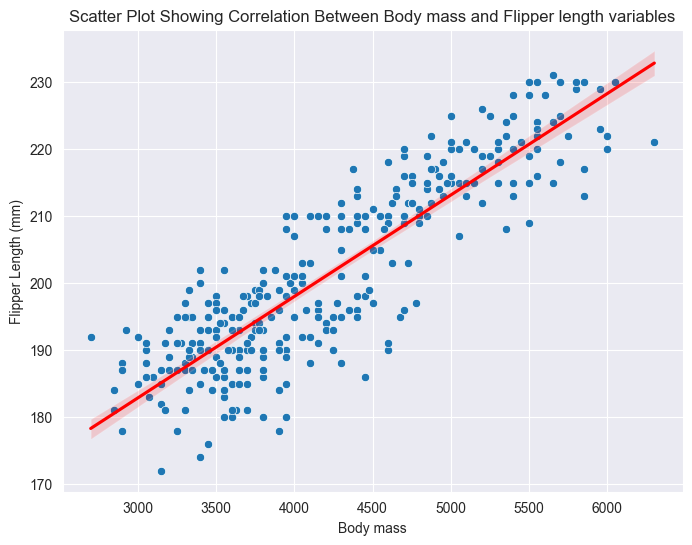

In [150]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Body_mass'], y=df['Flipper Length (mm)'])
sns.regplot(x=df['Body_mass'], y=df['Flipper Length (mm)'], scatter=False, color='red') 
plt.xlabel("Body mass")
plt.ylabel("Flipper Length (mm)")
plt.title("Scatter Plot Showing Correlation Between Body mass and Flipper length variables")
plt.show()

<b style='color:green'> There is strong correlation between this two variables </b>